# WACC Sweep (C1-C9) and VOLL Sensitivity

Two exploratory analyses, kept in their own notebook rather than added to
`Paper2_2030.ipynb` (the B1 vs B2 headline comparison), since they answer
different questions and mixing them risks the kind of cell-order confusion
that happened earlier in this project.

**WACC sweep**: solar/wind WACC from 7% to 15% in 1pp steps, gas fixed at
Hatton's 14.68%. Identifies whether there is a threshold, or a continuum,
over which renewables gain share (Chapter 5, Section 5.4.2).

**VOLL sensitivity**: how much the build and the unserved energy depend on
the value of lost load assumption, at Hatton (B2) financing. Raised by
your supervisor's question about whether load shedding is being modelled
realistically.

**Resolution note**: both sets of runs used `opts: [3h]`, not the `1h`
used for the B1/B2 headline comparison. State this if these figures are
reported alongside the headline result, since they are not directly
comparable at the snapshot level (though aggregate GW and TWh figures are
still meaningful).

In [6]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

EUR_PER_USD = 0.7532
USD_PER_EUR = 1 / EUR_PER_USD

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def get_connected(n):
    """Returns bus names on the main grid, excluding OSM-derived isolated
    buses with no transmission line (see the 2024 validation notebook for
    where this was first diagnosed)."""
    n.determine_network_topology()
    main_sub = n.buses.sub_network.mode()[0]
    return n.buses.index[n.buses.sub_network == main_sub].tolist()

def load_and_summarize(path, label):
    n = pypsa.Network(path)
    connected = get_connected(n)
    gens = n.generators[n.generators.bus.isin(connected)]
    new = (gens.p_nom_opt - gens.p_nom).clip(lower=0)
    by_carrier = new.groupby(gens.carrier).sum() / 1e3  # GW

    w = n.snapshot_weightings.objective
    capex_usd = (new * gens.capital_cost).sum() * USD_PER_EUR
    ls = gens[gens.carrier == "load shedding"]
    shed_twh = (n.generators_t.p[ls.index].mul(w, axis=0).sum().sum() / 1e6
                if len(ls) else 0)
    excluded = [b for b in n.buses.index if b not in connected]

    return {"label": label, "n": n, "connected": connected, "excluded": excluded,
            "new_by_carrier": by_carrier, "capex_usd": capex_usd, "shed_twh": shed_twh}

## 1. WACC sweep: load and check comparability

In [7]:
sweep_paths = {
    i: f"/Users/fowfloi/Documents/pypsa-earth/results/cap_exp_2030_C{i}/networks/elec_s_10_ec_lcopt_1h.nc"
    for i in range(1, 10)
}

sweep_results = []
for i, path in sweep_paths.items():
    r = load_and_summarize(path, f"C{i} ({6+i}%)")
    sweep_results.append(r)
    n = r["n"]
    w = n.snapshot_weightings.objective
    d = n.loads_t.p_set.sum(axis=1).mul(w).sum() / 1e6
    print(f"C{i} (solar/wind {6+i}%): {len(n.snapshots)} snapshots, "
          f"demand {d:.2f} TWh, excluded buses {r['excluded']}")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units


C1 (solar/wind 7%): 8784 snapshots, demand 77.78 TWh, excluded buses ['NG1 0', 'NG2 0']
C2 (solar/wind 8%): 8784 snapshots, demand 77.78 TWh, excluded buses ['NG1 0', 'NG2 0']


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units


C3 (solar/wind 9%): 8784 snapshots, demand 77.78 TWh, excluded buses ['NG1 0', 'NG2 0']
C4 (solar/wind 10%): 8784 snapshots, demand 77.78 TWh, excluded buses ['NG1 0', 'NG2 0']


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units


C5 (solar/wind 11%): 8784 snapshots, demand 77.78 TWh, excluded buses ['NG1 0', 'NG2 0']
C6 (solar/wind 12%): 8784 snapshots, demand 77.78 TWh, excluded buses ['NG1 0', 'NG2 0']


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units


C7 (solar/wind 13%): 8784 snapshots, demand 77.78 TWh, excluded buses ['NG1 0', 'NG2 0']
C8 (solar/wind 14%): 8784 snapshots, demand 77.78 TWh, excluded buses ['NG1 0', 'NG2 0']


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units


C9 (solar/wind 15%): 8784 snapshots, demand 77.78 TWh, excluded buses ['NG1 0', 'NG2 0']


Check before trusting anything below: all nine lines should show the same
demand and snapshot count. If `excluded` differs across runs, the isolated
bus set is not stable across the sweep and the connected-grid comparison
needs a closer look before proceeding.

## 2. WACC sweep: new build vs solar/wind cost of capital

carrier   CCGT   OCGT  load shedding  onwind  solar  wacc_pct
C1 (7%)    0.0   0.00            0.0     0.0  24.17         7
C2 (8%)    0.0   4.44            0.0     0.0  18.72         8
C3 (9%)    0.0  10.66            0.0     0.0  10.76         9
C4 (10%)   0.0  11.45            0.0     0.0   9.37        10
C5 (11%)   0.0  12.15            0.0     0.0   8.22        11
C6 (12%)   0.0  12.61            0.0     0.0   7.45        12
C7 (13%)   0.0  13.37            0.0     0.0   6.37        13
C8 (14%)   0.0  14.11            0.0     0.0   5.32        14
C9 (15%)   0.0  14.85            0.0     0.0   4.37        15


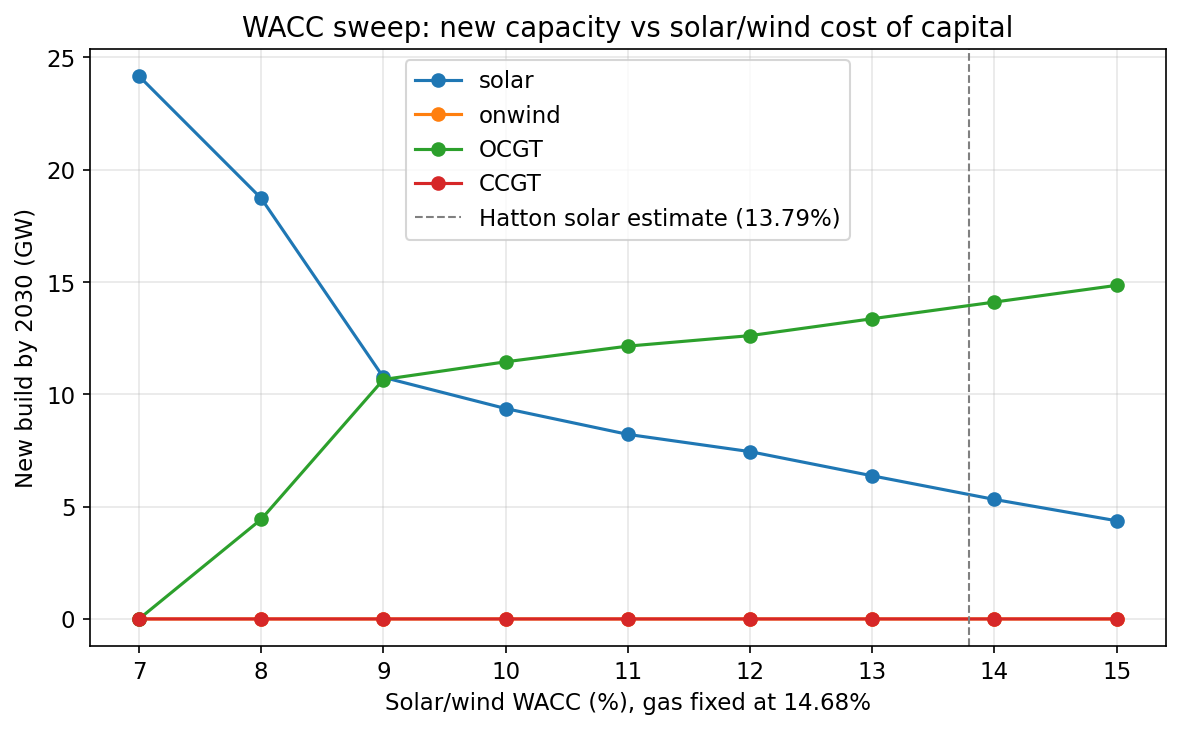

In [8]:
sweep_df = pd.DataFrame({
    r["label"]: r["new_by_carrier"] for r in sweep_results
}).T.fillna(0)
sweep_df["wacc_pct"] = range(7, 16)

print(sweep_df.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
for carrier in ["solar", "onwind", "OCGT", "CCGT"]:
    if carrier in sweep_df.columns:
        ax.plot(sweep_df["wacc_pct"], sweep_df[carrier], marker="o", label=carrier)
ax.axvline(13.79, color="grey", ls="--", lw=1, label="Hatton solar estimate (13.79%)")
ax.set_xlabel("Solar/wind WACC (%), gas fixed at 14.68%")
ax.set_ylabel("New build by 2030 (GW)")
ax.set_title("WACC sweep: new capacity vs solar/wind cost of capital")
ax.legend()
plt.tight_layout()
plt.savefig("fig_wacc_sweep.png", bbox_inches="tight")
plt.show()

**Reading this chart**: look for whether solar's line rises smoothly as
WACC falls (a continuum, as the framework document frames it) or whether
there is a sharp step at some WACC value (closer to a threshold). Note
where the Hatton estimate (13.79%) sits on that curve relative to C1 (7%,
the most favourable end): that comparison is effectively what B2 already
showed, so it should be consistent with the B1/B2 result in the other
notebook.

## 3. WACC sweep: system cost

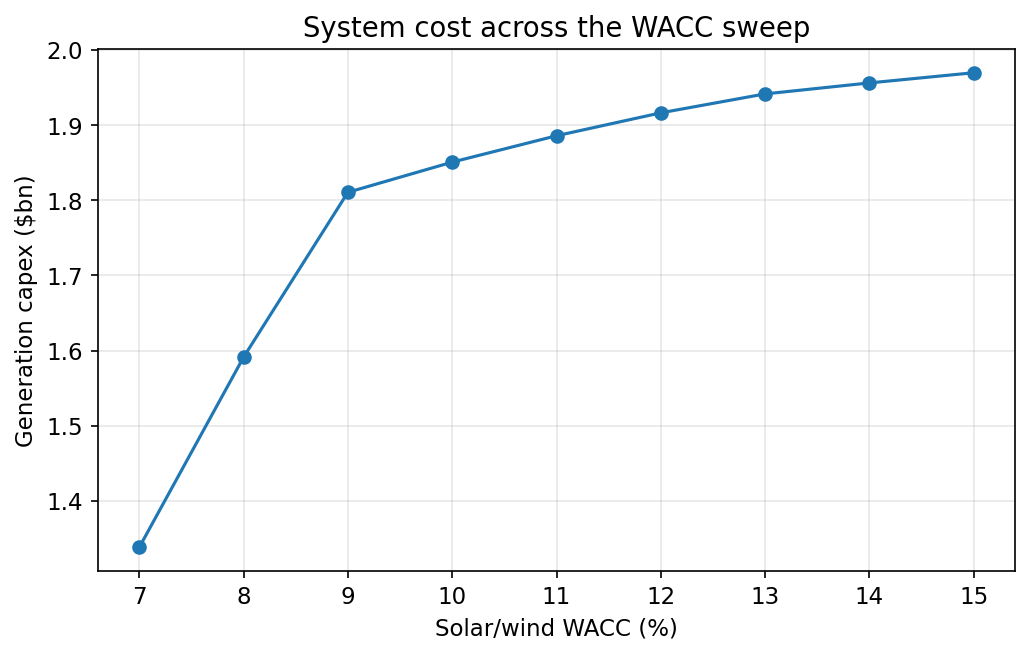

   wacc_pct     capex_usd  shed_twh
0         7  1.338155e+09     0.000
1         8  1.591203e+09     0.000
2         9  1.810568e+09     0.001
3        10  1.850703e+09     0.007
4        11  1.885802e+09     0.019
5        12  1.916291e+09     0.026
6        13  1.941485e+09     0.050
7        14  1.956096e+09     0.057
8        15  1.969645e+09     0.074


In [9]:
cost_df = pd.DataFrame({
    "wacc_pct": range(7, 16),
    "capex_usd": [r["capex_usd"] for r in sweep_results],
    "shed_twh": [r["shed_twh"] for r in sweep_results],
})

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(cost_df.wacc_pct, cost_df.capex_usd / 1e9, "o-", color="tab:blue")
ax.set_xlabel("Solar/wind WACC (%)")
ax.set_ylabel("Generation capex ($bn)")
ax.set_title("System cost across the WACC sweep")
plt.tight_layout()
plt.savefig("fig_wacc_sweep_cost.png", bbox_inches="tight")
plt.show()

print(cost_df.round(3).to_string())

## 4. VOLL sensitivity: load and check

In [11]:
voll_configs = {"V1_cng": 0.13, "V2_diesel": 0.32, "V3_petrol": 0.55, "V4_nearzero": 0.0001}

voll_results = []
for k, voll in voll_configs.items():
    path = f"results/cap_exp_2030_voll_{k}/networks/elec_s_10_ec_lcopt_1h.nc"
    r = load_and_summarize(path, k)
    voll_results.append(r)
    n = r["n"]
    print(f"{k} (VOLL {voll}): excluded buses {r['excluded']}, "
          f"load_shedding in meta = {n.meta['solving']['options']['load_shedding']}")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units


V1_cng (VOLL 0.13): excluded buses ['NG1 0', 'NG2 0'], load_shedding in meta = 0.13
V2_diesel (VOLL 0.32): excluded buses ['NG1 0', 'NG2 0'], load_shedding in meta = 0.32


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units


V3_petrol (VOLL 0.55): excluded buses ['NG1 0', 'NG2 0'], load_shedding in meta = 0.55
V4_nearzero (VOLL 0.0001): excluded buses ['NG1 0', 'NG2 0'], load_shedding in meta = 0.0001


Confirm the `load_shedding` value printed for each run matches the
intended VOLL exactly. V4 is a near-zero placeholder rather than literal
0, since a literal 0 disables the shedding generator entirely (Python
treats `0` as falsy in the check that adds it), which caused an
infeasible solve earlier in this project rather than free shedding.

## 5. VOLL sensitivity: unserved energy and build cost

   VOLL_EUR_kWh  shed_TWh     capex_USD
0        0.1300    0.2617  1.952025e+09
1        0.3200    0.0527  1.952930e+09
2        0.5500    0.0197  1.954439e+09
3        0.0001   71.8205  1.023960e+01


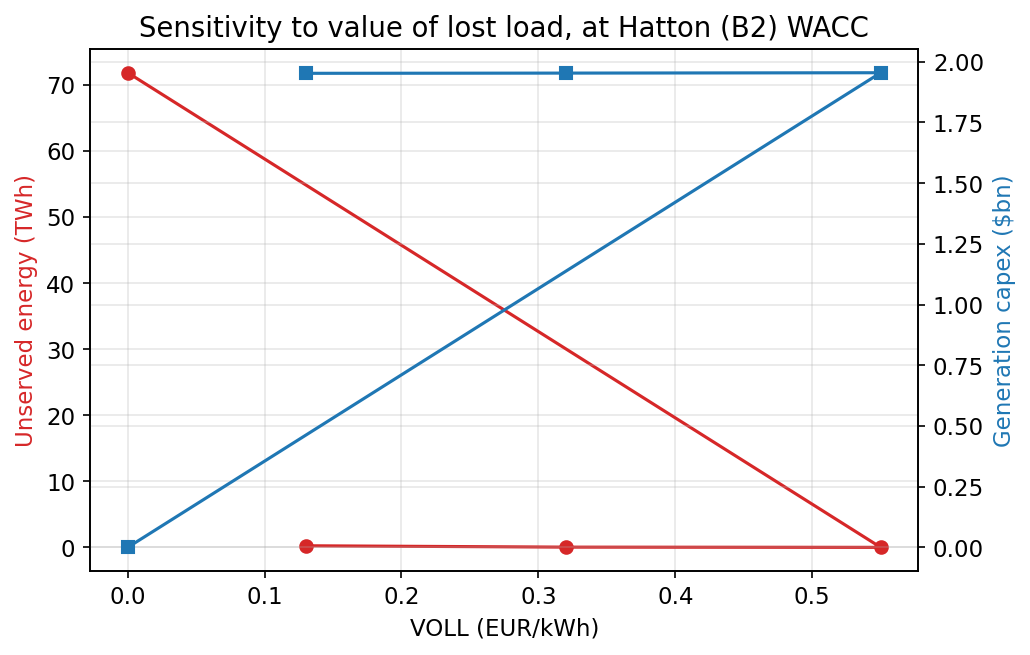

In [12]:
voll_df = pd.DataFrame({
    "VOLL_EUR_kWh": list(voll_configs.values()),
    "shed_TWh": [r["shed_twh"] for r in voll_results],
    "capex_USD": [r["capex_usd"] for r in voll_results],
})
print(voll_df.round(4).to_string())

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()
ax1.plot(voll_df.VOLL_EUR_kWh, voll_df.shed_TWh, "o-", color="tab:red", label="Unserved energy")
ax2.plot(voll_df.VOLL_EUR_kWh, voll_df.capex_USD / 1e9, "s-", color="tab:blue", label="Generation capex")
ax1.set_xlabel("VOLL (EUR/kWh)")
ax1.set_ylabel("Unserved energy (TWh)", color="tab:red")
ax2.set_ylabel("Generation capex ($bn)", color="tab:blue")
ax1.set_title("Sensitivity to value of lost load, at Hatton (B2) WACC")
plt.tight_layout()
plt.savefig("fig_voll_sensitivity.png", bbox_inches="tight")
plt.show()

**What this tells your supervisor**: if `shed_TWh` and `capex_USD`
change only modestly from V1 to V3 (the realistic self-generation cost
range), the B1/B2 result is robust to the VOLL assumption and the WACC
differentiation finding stands on its own. If either figure swings
sharply across that range, VOLL is a material driver of the result and
needs to be reported as an assumption the conclusion depends on, not a
fixed technical parameter.

## Scope note

Both analyses used `opts: [3h]` rather than the `1h` in the B1/B2 headline
run, to make nine-plus solves tractable. If any figure here is reported
alongside the B1/B2 result, note the resolution difference. If the
headline result needs to be defended at 1h specifically, the sweep and
VOLL configs can be regenerated at 1h with the same scripts, at the cost
of considerably longer solve time.